In [1]:
import os
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = 'D:/data/tumor-controller'
tumor_dir = os.path.join(data_dir, 'tumor')
normal_dir = os.path.join(data_dir, 'healthy')

stats = pd.read_csv(os.path.join(data_dir, 'normalization_minmax_stats.csv'))

In [3]:
t1ce_brains = [os.path.join(tumor_dir, f) for f in os.listdir(tumor_dir) if ('brain' in f) and ('-t1ce-') in f]

In [4]:
t1ce_brain = t1ce_brains[250]
t1ce_edge = t1ce_brain.replace('-brain-', '-edge-')

t2_brain = t1ce_brain.replace('-t1ce-', '-t2-')
t2_edge = t2_brain.replace('-brain-', '-edge-')

seg = t1ce_brain.replace('-brain-', '-seg-').replace('-t1ce', '')

print(t1ce_brain)
print(t1ce_edge)
print(t2_brain)
print(t2_edge)
print(seg)

D:/data/tumor-controller\tumor\021-brain-t1ce-106.pkl
D:/data/tumor-controller\tumor\021-edge-t1ce-106.pkl
D:/data/tumor-controller\tumor\021-brain-t2-106.pkl
D:/data/tumor-controller\tumor\021-edge-t2-106.pkl
D:/data/tumor-controller\tumor\021-seg-106.pkl


In [11]:
with open(t2_brain, 'rb') as fb:
    brain = pickle.load(fb)
    brain = brain.squeeze()
print(brain.shape)

(256, 256)


In [12]:
brain

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

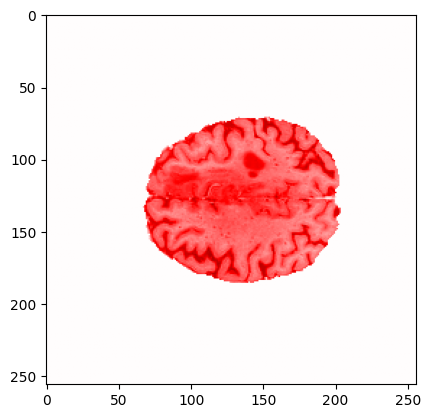

In [13]:
plt.imshow(brain, cmap='seismic', vmin=-1, vmax=1)
plt.show()

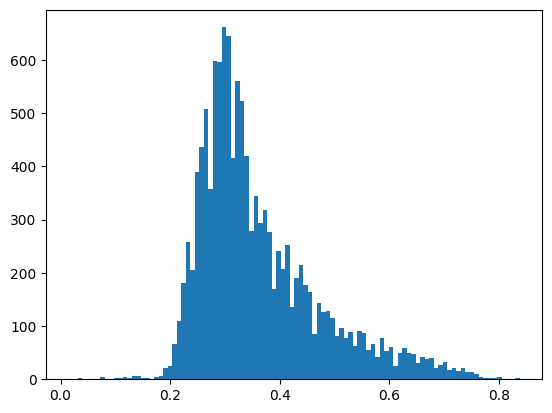

In [14]:
plt.hist(brain[brain != 0].flatten(), bins=100)
plt.show()

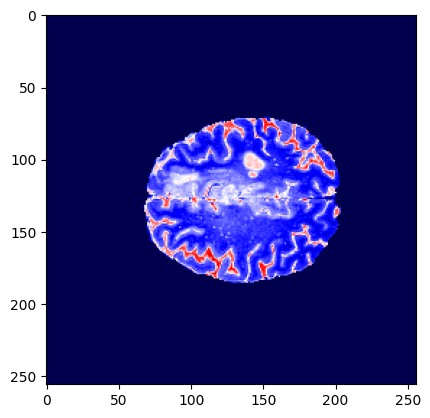

In [15]:
brain_ = (brain - 0.5) / 0.5
plt.imshow(brain_, cmap='seismic', vmin=-1, vmax=1)
plt.show()


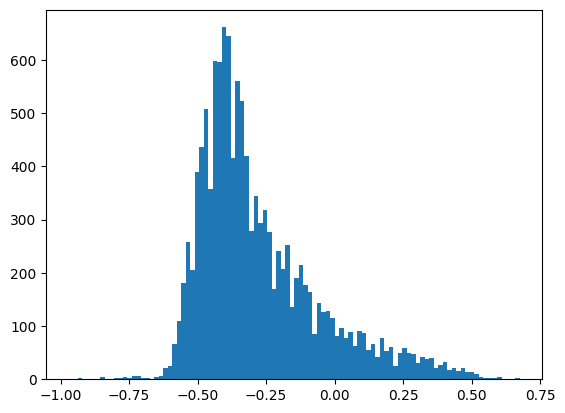

In [18]:
plt.hist(brain_[brain_ != -1].flatten(), bins=100)
plt.show()